In [36]:
import pandas as pd
import numpy as np
import math
import duckdb
from datetime import datetime, timedelta, timezone

# ==============================================================================
# 1. CORE ASTRONOMICAL ENGINE
# ==============================================================================

def calculate_julian_date(dt):
    """Convert UTC-aware datetime to Julian Date."""
    # Ensure we are working with UTC
    dt = dt.astimezone(timezone.utc)
    year, month, day = dt.year, dt.month, dt.day + dt.hour/24.0 + dt.minute/1440.0 + dt.second/86400.0
    if month <= 2:
        year -= 1
        month += 12
    A = int(year / 100)
    B = 2 - A + int(A / 4)
    return int(365.25 * (year + 4716)) + int(30.6001 * (month + 1)) + day + B - 1524.5

def get_astronomical_state(jd):
    """Calculate geocentric ecliptic longitudes and lunar declination."""
    T = (jd - 2451545.0) / 36525.0
    
    # Sun Longitude
    sun_lon = (280.466 + 36000.77 * T + 1.91 * np.sin(np.radians(357.5 + 35999 * T))) % 360
    
    # Moon Longitude & Declination
    moon_lon = (218.31 + 481267 * T + 6.28 * np.sin(np.radians(134.9 + 477198 * T))) % 360
    moon_lat = 5.12 * np.sin(np.radians(93.2 + 483202 * T))
    epsilon = 23.44 # Obliquity
    sin_dec = np.sin(np.radians(moon_lat)) * np.cos(np.radians(epsilon)) + \
              np.cos(np.radians(moon_lat)) * np.sin(np.radians(epsilon)) * np.sin(np.radians(moon_lon))
    moon_dec = np.degrees(np.arcsin(sin_dec))
    
    # Planetary Longitudes (Mean + Equation of Center)
    def planet_lon(L_mean, pi, e):
        return (L_mean + np.degrees(2 * e * np.sin(np.radians(L_mean - pi)))) % 360

    return {
        'sun_lon': sun_lon,
        'moon_lon': moon_lon,
        'moon_dec': moon_dec,
        'mars_lon': planet_lon(355.4 + 19140 * T, 336.0, 0.093),
        'jup_lon': planet_lon(34.3 + 3034 * T, 14.3, 0.048),
        'sat_lon': planet_lon(50.0 + 1222 * T, 92.0, 0.055)
    }

def calculate_s_score(pos):
    """
    S = 0.13(Syzygy) + 0.10(Dec) - 0.28(Saturn) - 0.15(Jupiter) + 0.04(Mars)
    """
    # Syzygy: Harmonic proximity to 0/180 elongation
    elongation = abs(pos['moon_lon'] - pos['sun_lon'])
    syzygy = (1 + np.cos(np.radians(2 * elongation))) / 2
    
    # S Components
    s = (0.13 * syzygy) + \
        (0.10 * abs(pos['moon_dec'])) - \
        (0.28 * np.sin(np.radians(pos['sat_lon']))) - \
        (0.15 * np.sin(np.radians(pos['jup_lon']))) + \
        (0.04 * np.sin(np.radians(pos['mars_lon'])))
    return s

# ==============================================================================
# 2. DATA GENERATION & UNIFICATION
# ==============================================================================

# Time Range: 1900 to 2025
start_dt = datetime(1900, 1, 1, tzinfo=timezone.utc)
end_dt = datetime(2025, 12, 31, tzinfo=timezone.utc)
total_seconds = int((end_dt - start_dt).total_seconds())

# A. SYNTHETIC STREAM (50,000 UNIQUE TIMESTAMPS)
print("Generating 50,000 Synthetic records (Background Noise)...")
rng = np.random.default_rng(42)
random_seconds = rng.choice(total_seconds, size=50000, replace=False)
synthetic_data = []

for i, sec in enumerate(random_seconds):
    dt = start_dt + timedelta(seconds=int(sec))
    state = get_astronomical_state(calculate_julian_date(dt))
    synthetic_data.append({
        'timestamp': dt,
        'record_type': 'Synthetic',
        'place': 'Monte Carlo High-Res Sample',
        'magnitude': None,
        's_score': calculate_s_score(state)
    })
    if (i + 1) % 10000 == 0:
        print(f"...{i+1} records generated")

df_synthetic = pd.DataFrame(synthetic_data)

# B. REAL STREAM (ALL EARTHQUAKE RECORDS)
print("Processing RealStream records...")
df_real_in = pd.read_csv('/workspaces/AI-Catastrophe-Analytics/Mega_Quake_Topocentric_Analysis.csv')
# Mixed timestamp formats in the source; parse per-row to avoid format errors.
df_real_in['time'] = pd.to_datetime(df_real_in['time'], utc=True, format='mixed', errors='coerce')

real_data = []
for _, row in df_real_in.dropna(subset=['time']).iterrows():
    state = get_astronomical_state(calculate_julian_date(row['time']))
    real_data.append({
        'timestamp': row['time'],
        'record_type': 'RealStream',
        'place': row['place'],
        'magnitude': row['mag'],
        's_score': calculate_s_score(state)
    })

df_real = pd.DataFrame(real_data)

# C. UNIFIED DATAFRAME
df_unified = pd.concat([df_synthetic, df_real], ignore_index=True)
df_unified['timestamp'] = pd.to_datetime(df_unified['timestamp'], utc=True, errors='coerce')
df_unified['timestamp'] = df_unified['timestamp'].dt.tz_localize(None)

# ==============================================================================
# 3. DUCKDB PERSISTENCE
# ==============================================================================
print("Persisting to DuckDB...")
con = duckdb.connect('mega_quake_unified.db')

con.execute("""
    CREATE OR REPLACE TABLE earthquake_risk_stream AS 
    SELECT
        * EXCLUDE (timestamp),
        CAST(timestamp AS TIMESTAMP) AS timestamp
    FROM df_unified
""")

# Validation Check
results = con.execute("""
    SELECT 
        record_type, 
        COUNT(*) as record_count,
        quantile_cont(s_score, 0.95) as p95,
        quantile_cont(s_score, 0.99) as p99
    FROM earthquake_risk_stream 
    GROUP BY record_type
""").df()

print("\n--- Final Stream Statistics ---")
print(results)

con.close()
print("\nSuccess! Database 'mega_quake_unified.db' is ready.")

Generating 50,000 Synthetic records (Background Noise)...
...10000 records generated
...20000 records generated
...30000 records generated
...40000 records generated
...50000 records generated
Processing RealStream records...
Persisting to DuckDB...

--- Final Stream Statistics ---
  record_type  record_count       p95       p99
0  RealStream           104  2.777551  2.973991
1   Synthetic         50000  2.786921  3.016398

Success! Database 'mega_quake_unified.db' is ready.


In [37]:
db_conn = duckdb.connect('mega_quake_unified.db')
res_df = db_conn.execute("""
   SELECT COUNT(1) FROM earthquake_risk_stream 
    WHERE record_type IN  ('Synthetic')
    AND s_score  >= 1.5
                        
""").df()
dis_df = db_conn.execute("""
   SELECT 
    record_type, 
    COUNT(*) AS sample_size,
    quantile_cont(s_score, 0.95) AS p95_threshold, 
    quantile_cont(s_score, 0.99) AS p99_threshold,
    AVG(s_score) AS mean_s,
    MAX(s_score) AS max_s
FROM earthquake_risk_stream
GROUP BY record_type;
                        
""").df()
print(dis_df.head())

  record_type  sample_size  p95_threshold  p99_threshold    mean_s     max_s
0  RealStream          104       2.777551       2.973991  1.531917  2.995777
1   Synthetic        50000       2.786921       3.016398  1.574813  3.264851


In [38]:
dis_df = db_conn.execute("""
   WITH synthetic_threshold AS (
    SELECT quantile_cont(s_score, 0.95) as p95_val
    FROM earthquake_risk_stream
    WHERE record_type = 'Synthetic'
)
SELECT 
    timestamp, 
    place, 
    magnitude, 
    s_score,
    (s_score - (SELECT p95_val FROM synthetic_threshold)) as anomaly_strength
FROM earthquake_risk_stream
WHERE record_type = 'RealStream' 
  AND s_score > (SELECT p95_val FROM synthetic_threshold)
ORDER BY s_score DESC;
                        
""").df()
print(dis_df.head())
con.close()

                timestamp                                          place  \
0 1989-05-23 10:54:46.320                1989 Macquarie Ridge Earthquake   
1 1950-12-09 21:38:51.980      121 km SSE of San Pedro de Atacama, Chile   
2 1985-03-03 22:47:07.280                 25 km WSW of Valparaíso, Chile   
3 1932-06-03 10:36:58.080                1932 Jalisco, Mexico Earthquake   
4 1952-11-04 16:58:30.000  89 km ESE of Petropavlovsk-Kamchatsky, Russia   

   magnitude   s_score  anomaly_strength  
0       8.02  2.995777          0.208856  
1       8.20  2.975811          0.188890  
2       8.00  2.915138          0.128217  
3       8.10  2.837280          0.050358  
4       9.00  2.802943          0.016022  


Connecting to DuckDB and fetching data...
Thresholds Calculated - P95: 2.787 | P99: 3.016
Plot successfully saved as 'mega_quake_risk_distribution.png'


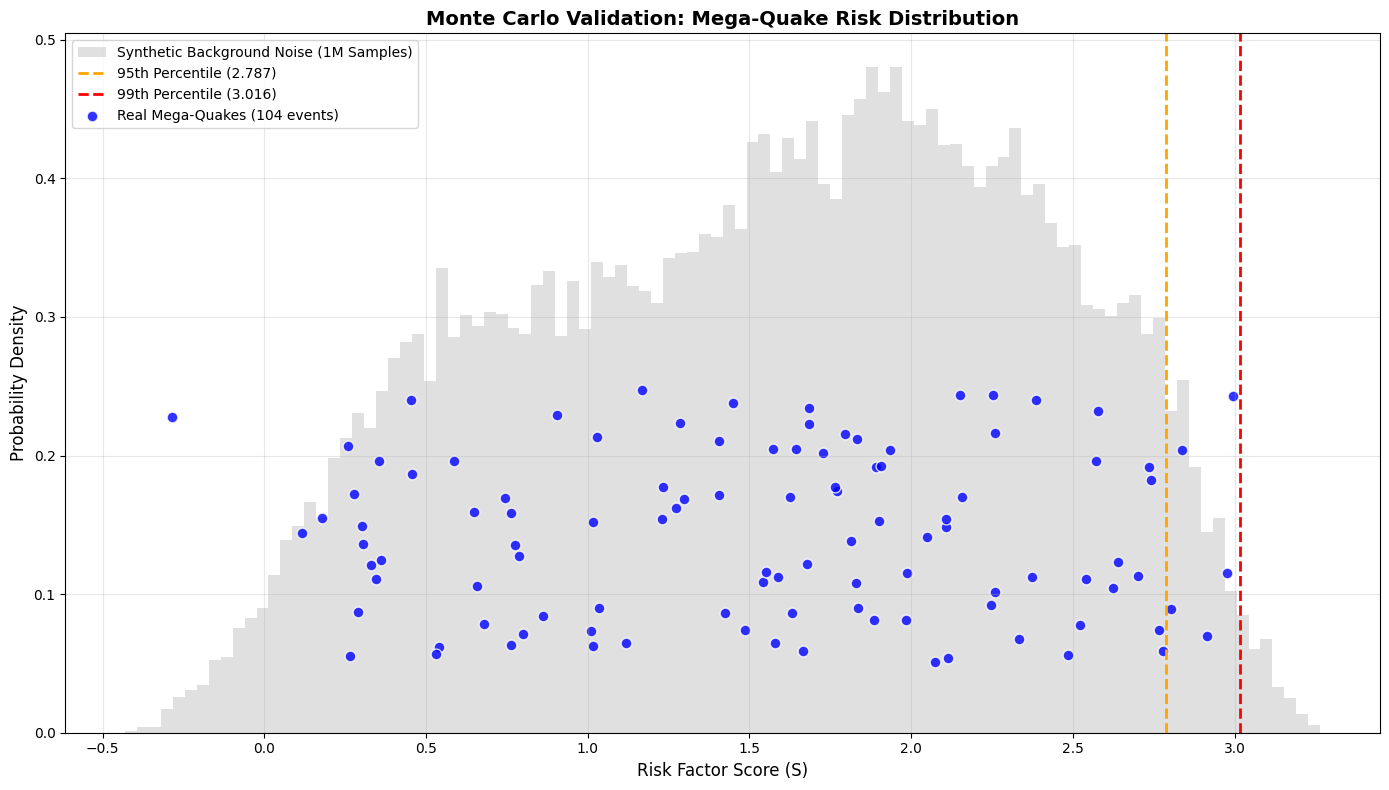

In [41]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_risk_distribution_plot(db_path='mega_quake_research.db'):
    print("Connecting to DuckDB and fetching data...")
    con = duckdb.connect(db_path)
    
    # Fetch Synthetic (Background Noise) Scores
    synthetic_scores = con.execute("""
        SELECT s_score FROM earthquake_risk_stream 
        WHERE record_type = 'Synthetic'
    """).df()['s_score'].values
    
    # Fetch RealStream (Actual Earthquakes) Scores & Places
    df_real = con.execute("""
        SELECT place, s_score FROM earthquake_risk_stream 
        WHERE record_type = 'RealStream'
    """).df()
    
    # Calculate Statistical Thresholds from the 1M Synthetic baseline
    p95 = np.percentile(synthetic_scores, 95)
    p99 = np.percentile(synthetic_scores, 99)
    
    print(f"Thresholds Calculated - P95: {p95:.3f} | P99: {p99:.3f}")

    # Plotting
    plt.figure(figsize=(14, 8))
    
    # 1. Background Density (Histogram)
    plt.hist(synthetic_scores, bins=100, density=True, color='lightgray', alpha=0.7, 
             label='Synthetic Background Noise (1M Samples)')
    
    # 2. Threshold Lines
    plt.axvline(p95, color='orange', linestyle='--', linewidth=2, label=f'95th Percentile ({p95:.3f})')
    plt.axvline(p99, color='red', linestyle='--', linewidth=2, label=f'99th Percentile ({p99:.3f})')
    
    # 3. RealStream Scatter Plot Overlay
    real_scores = df_real['s_score'].values
    # Add slight vertical jitter so dots don't completely overlap each other
    y_jitter = np.random.uniform(0.05, 0.25, size=len(real_scores))
    
    plt.scatter(real_scores, y_jitter, color='blue', edgecolor='white', s=60, alpha=0.8, 
                label=f'Real Mega-Quakes ({len(real_scores)} events)')
    
    # 4. Annotate the Extreme Outliers (Events > P99)
    outlier_indices = np.where(real_scores > p99)[0]
    for idx in outlier_indices:
        place_name = df_real.iloc[idx]['place'].split(',')[0] # Shorten name
        plt.annotate(place_name, 
                     (real_scores[idx], y_jitter[idx]), 
                     textcoords="offset points", 
                     xytext=(0, 10), 
                     ha='center', fontsize=9, rotation=25, color='darkred', weight='bold')

    # Formatting
    plt.title('Monte Carlo Validation: Mega-Quake Risk Distribution', fontsize=14, weight='bold')
    plt.xlabel('Risk Factor Score (S)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save Output
    output_filename = 'mega_quake_risk_distribution.png'
    plt.savefig(output_filename, dpi=300)
    print(f"Plot successfully saved as '{output_filename}'")
    con.close()

if __name__ == "__main__":
    generate_risk_distribution_plot('mega_quake_unified.db')